In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import akshare as ak

In [5]:
# 读取数据
raw_data=pd.read_excel("IMM_5.xlsx").iloc[:8688,2:7]

#计算ma20
ma20=raw_data['收盘价'].rolling(20).mean()
raw_data['ma20']=ma20

#计算bar波动 = (K线最高点-K线最低点)/上一根K线的收盘价
bar_flu=np.array([None])
for i in range(1,len(raw_data)):
    bar_f=(raw_data.loc[i,'最高价']-raw_data.loc[i,'最低价'])/raw_data.loc[i-1,'收盘价']
    bar_flu=np.append(bar_flu,bar_f)
raw_data['bar_flu']=bar_flu
data=raw_data.dropna()
data.index=range(len(data))

data

,交易时间,开盘价,最高价,最低价,收盘价,ma20,bar_flu
0,2024-11-04 11:10:00,5962.4,5967.4,5956.8,5959.8,5952.50,0.001778
1,2024-11-04 11:15:00,5959.4,5978.0,5958.0,5971.4,5955.55,0.003356
2,2024-11-04 11:20:00,5972.0,5982.2,5966.4,5975.0,5958.15,0.002646
3,2024-11-04 11:25:00,5976.0,5982.0,5962.6,5979.4,5960.23,0.003247
4,2024-11-04 11:30:00,5980.0,5985.0,5964.0,5971.2,5961.74,0.003512
...,...,...,...,...,...,...,...
8664,2025-07-30 14:40:00,6619.0,6622.8,6611.2,6613.0,6604.37,0.001752
8665,2025-07-30 14:45:00,6612.8,6616.0,6607.0,6609.4,6603.04,0.001361
8666,2025-07-30 14:50:00,6608.8,6617.2,6606.0,6612.4,6602.10,0.001695
8667,2025-07-30 14:55:00,6612.4,6616.0,6610.2,6613.0,6601.38,0.000877


In [6]:
#策略
data.loc[1,'position']=0
data

for i in range(1,len(data)):
    #无仓位时
    if data.loc[i,'position']==0:
        #做多开仓条件:
        #上一K线的 bar波动小于0.1% 
        #且当前K线的bar波动大于0.7% 
        #且当前K线收盘价大于上一K线的收盘价
        #那么下一根K线开盘买入做多
        if data.loc[i-1,'bar_flu']<0.001:
            if data.loc[i,'bar_flu']>0.007:
                if data.loc[i,'收盘价']>data.loc[i-1,'收盘价']:
                    data.loc[i+1,'position']=1
                    continue
        #做空开仓条件：
        #上一K线的bar波动小于0.1%
        #且当前bar波动大于0.4%
        #且当前K线收盘价小于上一K线的收盘价
        #那么下一根K线开盘卖出做空
        if data.loc[i-1,'bar_flu']<0.001:
            if data.loc[i,'bar_flu']>0.004:
                if data.loc[i,'收盘价']<data.loc[i-1,'收盘价']:
                    data.loc[i+1,'position']=-1    
                    continue
        #不操作
        data.loc[i+1,'position']=0
        continue

    #持有多头时
    if data.loc[i,'position']==1:
        #做多平仓条件
        if (data.loc[i,'ma20']-data.loc[i-1,'ma20'])/data.loc[i-1,'ma20']<-0.0005:
            data.loc[i+1,'position']=0
            continue   
        #做空开仓条件：
        if data.loc[i-1,'bar_flu']<0.001:
            if data.loc[i,'bar_flu']>0.004:
                if data.loc[i,'收盘价']<data.loc[i-1,'收盘价']:
                    data.loc[i+1,'position']=-1
                    continue
        #不操作
        data.loc[i+1,'position']=1
        continue
                          
    #空头时
    if data.loc[i,'position']==-1:
        #做空平仓条件
        if (data.loc[i,'ma20']-data.loc[i-1,'ma20'])/data.loc[i-1,'ma20']>0.0004:
            data.loc[i+1,'position']=0
            continue
        #做多开仓条件:
        if data.loc[i-1,'bar_flu']<0.001:
            if data.loc[i,'bar_flu']>0.007:
                if data.loc[i,'收盘价']>data.loc[i-1,'收盘价']:
                    data.loc[i+1,'position']=1
                    continue
        #不操作
        data.loc[i+1,'position']=-1
        continue

C:\Users\leexi\AppData\Local\Temp\ipykernel_13884\834279495.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[1,'position']=0
C:\Users\leexi\AppData\Local\Temp\ipykernel_13884\834279495.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[i+1,'position']=0


In [7]:
data['交易时间']=pd.to_datetime(data['交易时间'])
data.set_index('交易时间', inplace=True)

<Axes: title={'center': 'Position'}, xlabel='交易时间'>

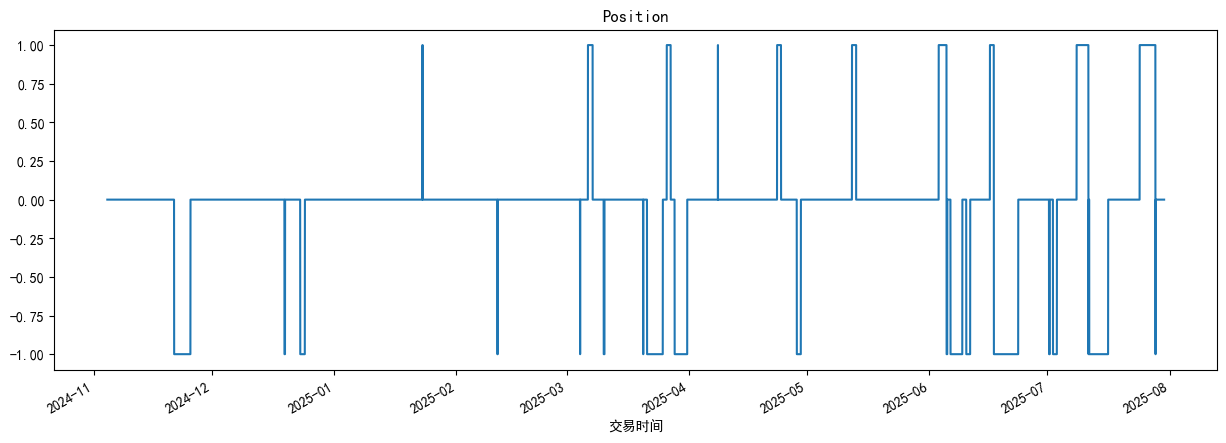

In [8]:
#买卖情况
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
data['position'].plot(figsize=(15, 5), title='Position')

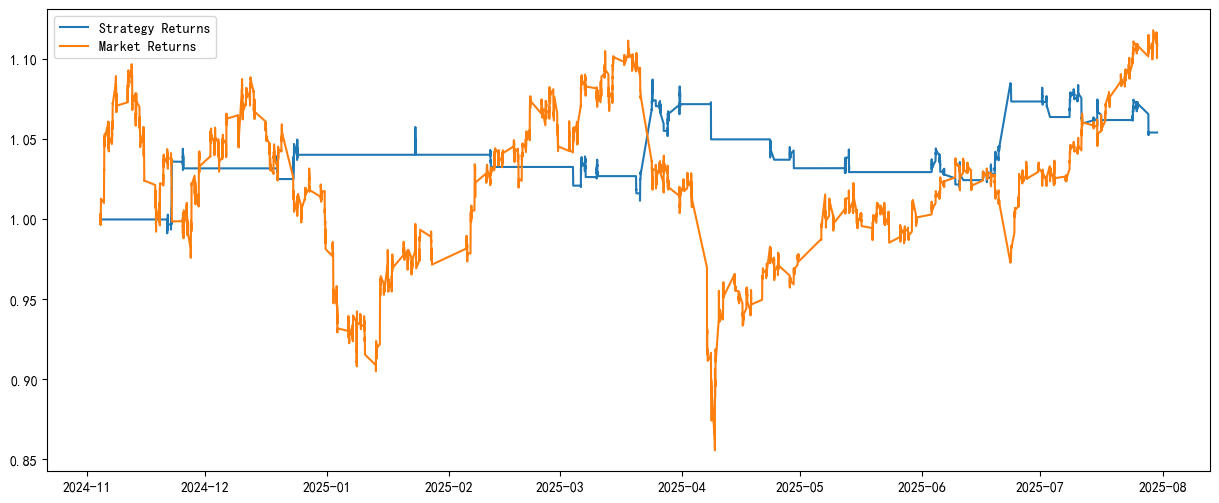

In [9]:
#计算策略收益率
data['r']=np.log(data['收盘价']/data['收盘价'].shift(1))
data.dropna(inplace=True)
data['s'] = data['position'] * data['r']
pc=0.00023 #交易成本
data['s_'] = np.where(data['position'].diff() != 0,data['s'] - pc, data['s'])
data[['r', 's_']].sum().apply(np.exp) 

#可视化
plt.figure(figsize=(15, 6))
plt.plot(data['s_'].cumsum().apply(np.exp), label='Strategy Returns')
plt.plot(data['r'].cumsum().apply(np.exp), label='Market Returns')
plt.legend()

In [10]:
import quantstats as qs
'''
qs.reports.html(data['s_'], 
               benchmark=data['r'], 
               output='quantstats_report.html', 
               title='My Strategy Report',       
               rf=0.02)            
'''

"\nqs.reports.html(data['s_'], \n               benchmark=data['r'], \n               output='quantstats_report.html', \n               title='My Strategy Report',       \n               rf=0.02)            \n"

In [11]:
def print_quantstats_metrics(returns, benchmark, rf=0):
    print("\n=== 基础收益率指标 ===")
    print(f"累计收益: {qs.stats.comp(returns):.2%}")
    print(f"年化收益率: {qs.stats.cagr(returns):.2%}")
    print(f"年化波动率: {qs.stats.volatility(returns):.2%}")
    
    print("\n=== 风险调整收益 ===")
    print(f"夏普比率: {qs.stats.sharpe(returns, rf=rf):.2f}")
    print(f"索提诺比率: {qs.stats.sortino(returns, rf=rf):.2f}")
    print(f"Calmar比率: {qs.stats.calmar(returns):.2f}")
    
    print("\n=== 回撤指标 ===")
    print(f"最大回撤: {qs.stats.max_drawdown(returns):.2%}")
    
    print("\n=== 基准对比 ===")
    print(f"信息比率: {qs.stats.information_ratio(returns, benchmark):.2f}")
    print(f"R平方: {qs.stats.r_squared(returns, benchmark):.2f}")

    print("\n=== 其他指标 ===")
    print(f"胜率: {qs.stats.win_rate(returns):.2%}")
    print(f"盈亏比: {qs.stats.profit_ratio(returns):.2f}")
    print(f"尾部比率: {qs.stats.tail_ratio(returns):.2f}")

# 执行打印
print_quantstats_metrics(data['s_'], data['r'])


=== 基础收益率指标 ===
累计收益: 5.04%
年化收益率: 4.73%
年化波动率: 1.42%

=== 风险调整收益 ===
夏普比率: 0.11
索提诺比率: 0.19
Calmar比率: 0.76

=== 回撤指标 ===
最大回撤: -6.23%

=== 基准对比 ===
信息比率: -0.00
R平方: 0.06

=== 其他指标 ===
胜率: 49.29%
盈亏比: 0.02
尾部比率: 1.02
